<a href="https://colab.research.google.com/github/malakagunasekara/imageprocessing/blob/main/Q2NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


In [10]:
uploaded = files.upload()

image_name = list(uploaded.keys())[0]


Saving highlights.png to highlights (1).png


In [11]:
# Read image
img_bgr = cv2.imread(image_name)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert RGB to L*a*b*
img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

# Split channels
L, a, b = cv2.split(img_lab)


In [12]:
# Normalize L channel to [0,1]
L_norm = L.astype(np.float32) / 255.0

# Gamma value
gamma = 2

# Apply gamma correction
L_gamma = np.power(L_norm, gamma)

# Scale back to [0,255]
L_gamma = np.uint8(L_gamma * 255)


In [13]:
# Merge corrected L with original a and b
lab_gamma = cv2.merge((L_gamma, a, b))

# Convert back to RGB
rgb_gamma = cv2.cvtColor(lab_gamma, cv2.COLOR_LAB2RGB)


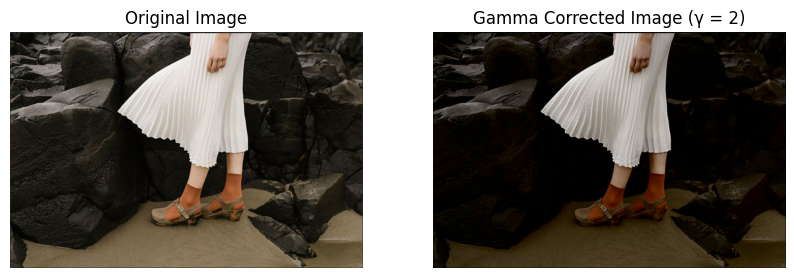

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb_gamma)
plt.title("Gamma Corrected Image (γ = 2)")
plt.axis("off")

plt.show()


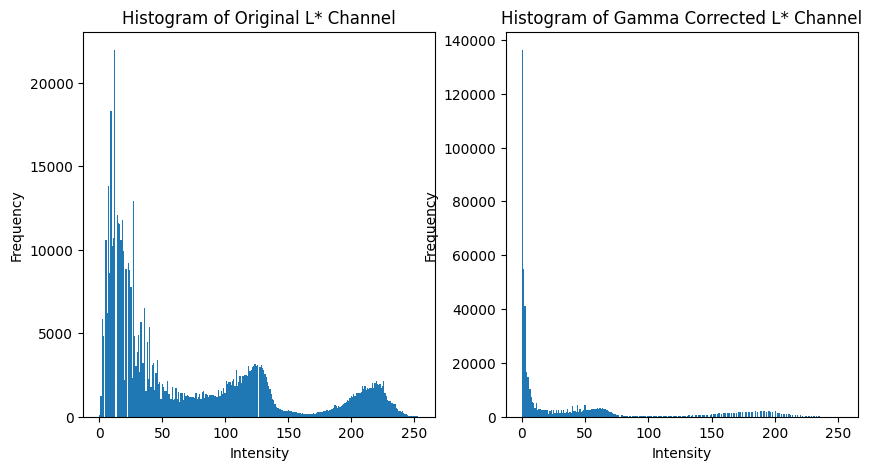

In [15]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(L.flatten(), bins=256)
plt.title("Histogram of Original L* Channel")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(L_gamma.flatten(), bins=256)
plt.title("Histogram of Gamma Corrected L* Channel")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()
